# Logistic Regression Model

The code below builds a baseline classification model for a consumer lending dataset. This includes dataset loading, data normalisation to improve model stability, model training, evaluation and tuning, followed by model testing and a discussion of the test results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model, metrics
from sklearn.preprocessing import StandardScaler

In [2]:
#reading the preprocessed datasets
train = pd.read_csv('train_processed.csv')
validation = pd.read_csv('validation_processed.csv')
test = pd.read_csv('validation_processed.csv')
train.head(2)

,loan_status,loan_amnt,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,...,verif__Not Verified,verif__Source Verified,verif__Verified,purpose__consumer_needs,purpose__credit_card,purpose__debt_consolidation,purpose__home_improvement,purpose__other,list__f,list__w
0,0,25000.0,19.20,11.938200,6.39,9.0,0,10.150348,49.6,21.0,...,0,0,1,0,0,1,0,0,1,0
1,1,5000.0,13.67,10.686567,6.23,14.0,1,8.822470,45.8,38.0,...,1,0,0,1,0,0,0,0,0,1


In [3]:
# Features and Label
# for train 
y_train = train['loan_status']
X_train = train.iloc[:, 1:]

# for validation
y_val = validation['loan_status']
X_val = validation.iloc[:, 1:]

# for test
y_test = test['loan_status']
X_test = test.iloc[:, 1:]

In [4]:
# Confirm the imbalance in the target variable frequencies once again
y_train.value_counts(normalize=True)

loan_status
0    0.802601
1    0.197399
Name: proportion, dtype: float64

## Data Normalisation

To improve model stability, I normalise the numerical features on the standard scale

In [5]:
# The list of the numerical features
columns_num = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 
           'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'delta_issue_earliest']

# The list of the encoded categorical features
columns_cat = ['pub_rec', 'mort_acc', 'pub_rec_bankruptcies', 'term__ 36 months', 'term__ 60 months',
              'emp__10+ years', 'emp__3-5 years', 'emp__6-9 years', 'emp__<=2 years', 
              'home__MORTGAGE', 'home__OTHERS','home__OWN', 'home__RENT', 
               'verif__Not Verified', 'verif__Source Verified', 'verif__Verified',
              'purpose__consumer_needs', 'purpose__credit_card','purpose__debt_consolidation',
              'purpose__home_improvement', 'purpose__other', 'list__f', 'list__w']

In [6]:
# Scaling the numerical featires to unit variance
std_scaler = StandardScaler()

# Fit to the training data and transform
X_train_scaled = std_scaler.fit_transform(X_train[columns_num])

# Transforming the validation and test data on the scale of the training data
X_val_scaled = std_scaler.transform(X_val[columns_num])
X_test_scaled = std_scaler.transform(X_test[columns_num])

In [7]:
# Convert the arrays to the Pandas dataframes
train_num_scaled = pd.DataFrame(X_train_scaled, columns = columns_num)
val_num_scaled = pd.DataFrame(X_val_scaled, columns = columns_num)
test_num_scaled = pd.DataFrame(X_test_scaled, columns = columns_num)

train_num_scaled.head(2)

,loan_amnt,int_rate,annual_inc,dti,open_acc,revol_bal,revol_util,total_acc,delta_issue_earliest
0,1.243952,1.198444,1.653493,-1.389759,-0.499299,0.810783,-0.198462,-0.406161,-1.015377
1,-1.135495,-0.028264,-0.811220,-1.409454,0.465383,-0.381006,-0.357267,1.021899,0.976272


In [8]:
# Categorical features
train_cat = X_train[columns_cat]
val_cat = X_val[columns_cat]
test_cat = X_test[columns_cat]

train_cat.head(2)

,pub_rec,mort_acc,pub_rec_bankruptcies,term__ 36 months,term__ 60 months,emp__10+ years,emp__3-5 years,emp__6-9 years,emp__<=2 years,home__MORTGAGE,...,verif__Not Verified,verif__Source Verified,verif__Verified,purpose__consumer_needs,purpose__credit_card,purpose__debt_consolidation,purpose__home_improvement,purpose__other,list__f,list__w
0,0,1,0,0,1,0,0,1,0,1,...,0,0,1,0,0,1,0,0,1,0
1,1,0,1,1,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,1


In [9]:
# Concatenation of the features into the datasets ready for training
X_tr_scaled = pd.concat([train_num_scaled, train_cat], axis=1)
X_val_scaled = pd.concat([val_num_scaled, val_cat], axis=1)
X_test_scaled = pd.concat([test_num_scaled, test_cat], axis=1)

X_tr_scaled.head(2)

,loan_amnt,int_rate,annual_inc,dti,open_acc,revol_bal,revol_util,total_acc,delta_issue_earliest,pub_rec,...,verif__Not Verified,verif__Source Verified,verif__Verified,purpose__consumer_needs,purpose__credit_card,purpose__debt_consolidation,purpose__home_improvement,purpose__other,list__f,list__w
0,1.243952,1.198444,1.653493,-1.389759,-0.499299,0.810783,-0.198462,-0.406161,-1.015377,0,...,0,0,1,0,0,1,0,0,1,0
1,-1.135495,-0.028264,-0.811220,-1.409454,0.465383,-0.381006,-0.357267,1.021899,0.976272,1,...,1,0,0,1,0,0,0,0,0,1


## Model Training

I will use the default solver 'lbfgs'since the train dataset contains more than 238k rows and the default solver is appropriate for this dataset size. the max iteration is set to 50, as the model converges relatively quickly after data normalisation.

In [10]:
estimator = linear_model.LogisticRegression(class_weight='balanced', max_iter=50)
estimator.fit(X_tr_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,50
,multi_class,'deprecated'


In [11]:
# Checking how many iterations were needed for the model to converge
print('The model converged at:', estimator.n_iter_, 'iterations')

The model converged at: [24] iterations


In [12]:
# Identifying the strongest predictors
coef = pd.DataFrame({'Feature': X_train.columns, 'Coefficients': estimator.coef_[0]})

coef.sort_values('Coefficients', key=abs, ascending=False).head(10)

,Feature,Coefficients
1,int_rate,0.456322
9,mort_acc,0.273631
11,delta_issue_earliest,-0.241859
13,term__ 60 months,0.237182
12,term__ 36 months,-0.230971
3,dti,0.203205
2,annual_inc,-0.187739
4,open_acc,0.162033
0,loan_amnt,0.139477
18,home__MORTGAGE,-0.131624


As I suspected during the EDA, *int_rate* is the strongest predictor, followed by the *mort_acc* and the time delta

## Model Validation and Tuning

First, I will assess the **Confusion Matrix**, as in the business context of credit risk assessment it is particularly useful for understanding how many defaults the model catches (Recall) and how many predicted defaults are actually defaults (Precision). 

Since I am dealing with an imbalanced dataset, with the event of interest - charged-off loans - being the minority class, the **F1 score**, which balances precision and recall, is prioritised as the primary metric for assessing model performance

In [13]:
y_train_pred = estimator.predict(X_tr_scaled)
y_val_pred = estimator.predict(X_val_scaled)

In [14]:
print('Train Confusion Matrix: \n', metrics.confusion_matrix(y_train, y_train_pred), '\n')
print('Train Recall:', round(metrics.recall_score(y_train, y_train_pred), 3))
print('Train Precision:', round(metrics.precision_score(y_train, y_train_pred), 3), '\n')
print('Validation Confusion Matrix: \n', metrics.confusion_matrix(y_val, y_val_pred), '\n')
print('Validation Recall:', round(metrics.recall_score(y_val, y_val_pred), 3))
print('Validation Precision:', round(metrics.precision_score(y_val, y_val_pred), 3), '\n')

Train Confusion Matrix: 
 [[126848  64606]
 [ 16795  30293]] 

Train Recall: 0.643
Train Precision: 0.319 

Validation Confusion Matrix: 
 [[27326 13700]
 [ 3716  6374]] 

Validation Recall: 0.632
Validation Precision: 0.318 



In [15]:
# How the model fits? Is it underfitting or overfitting? 
print('F1 score train:', round(metrics.f1_score(y_train, y_train_pred), 3))
print('F1 score valuation:', round(metrics.f1_score(y_val, y_val_pred), 3))

F1 score train: 0.427
F1 score valuation: 0.423


The modelThe model generalises quite well. There is no evidence of overfitting and, given the F1 score, it appears that the model has already extracted most of the available linear signal from the features. No further tuning of the hyperparameter C will be performed, as the default value of C=1 seems to be adequate. So I will use the initial estimator on the test set.

Let's determine the optimal classification threshold

In [16]:
y_val_score = estimator.predict_proba(X_val_scaled)[:, 1]
thresholds = np.arange(0.01, 1, 0.01)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    pred = (y_val_score >= t).astype(int)

    f1 = metrics.f1_score(y_val, pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print('The best Classification Threshold:', best_threshold)
print('The best F1 score:', round(best_f1, 3))

The best Classification Threshold: 0.49
The best F1 score: 0.424


Apparently, the default classification threshold is not that bad. I can adjust it slightly to 0.49

## Model Testing

In [17]:
# I use the initial model and apply the slightly adjusted threshold 0.49
y_test_score = estimator.predict_proba(X_test_scaled)[:,1]
y_test_pred = (y_test_score >= 0.49).astype(int)

In [18]:
print('Test Confusion Matrix: \n', metrics.confusion_matrix(y_test, y_test_pred), '\n')
print('Test Recall:', round(metrics.recall_score(y_test, y_test_pred), 3))
print('Test Precision:', round(metrics.precision_score(y_test, y_test_pred), 3), '\n')
print('F1 score test:', round(metrics.f1_score(y_test, y_test_pred), 3))

Test Confusion Matrix: 
 [[26546 14480]
 [ 3485  6605]] 

Test Recall: 0.655
Test Precision: 0.313 

F1 score test: 0.424


The model caught ≈65% of the defaults with a precision of ≈31%. At the chosen threshold, the balance between precision and recall gives an F1 score of ≈0.42. The model generalises quite well, as the test F1 score is close to the respective score on the validation dataset

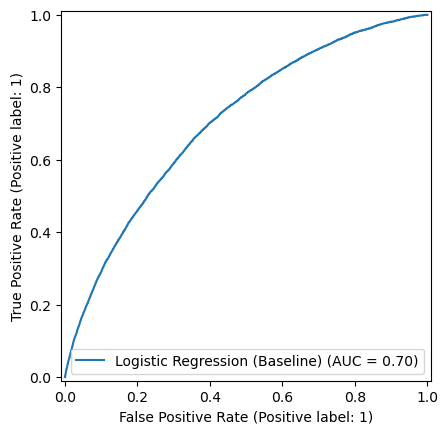

In [19]:
metrics.RocCurveDisplay.from_predictions(y_test, y_test_score, name='Logistic Regression (Baseline)')
plt.show()

The model ranks borrowers reasonably well, as the AUC is 0.70, meaning that 70% of the time the model ranks a bad borrower above a good borrower

## Conclusion

The Logistic Regression model achieved an **F1 score** of **0.424** with a **recall** of **65.5%**, indicating that it correctly identifies approximately two-thirds of defaulting borrowers. Training, validation and test performance were nearly identical, suggesting good generalisation and minimal overfitting. Hence, the model therefore provides a solid baseline. However, its performance seems to be constrained by the linear assumptions of the Logistic Regression.

**Top Predictors:**

| Feature | Coefficient | 
|:-----------|:------------:|
| int_rate   |  0.456   | 
| mort_acc        |  0.274 | 
| delta_issue_earliest|-0.241|
| term__ 60 months	 |0.237|
| term__ 36 months	 |-0.231|

**Summary of the Test Metrics:**

| Metrics | Model Performance | 
|:-----------|:------------:|
| F1 Score   |  0.424   | 
| Precision        |  0.313 | 
| Recall|0.655|
| AUC |0.700|
